## Data Preprocessing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 6.5 MB/s eta 0:00:00
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species  \
0   1            5.1           3.5            1.4           0.2  Iris-setosa   
1   2            4.9           3.0            1.4           0.2  Iris-setosa   
2   3            4.7           3.2            1.3           0.2  Iris-setosa   
3   4            4.6           3.1            1.5         

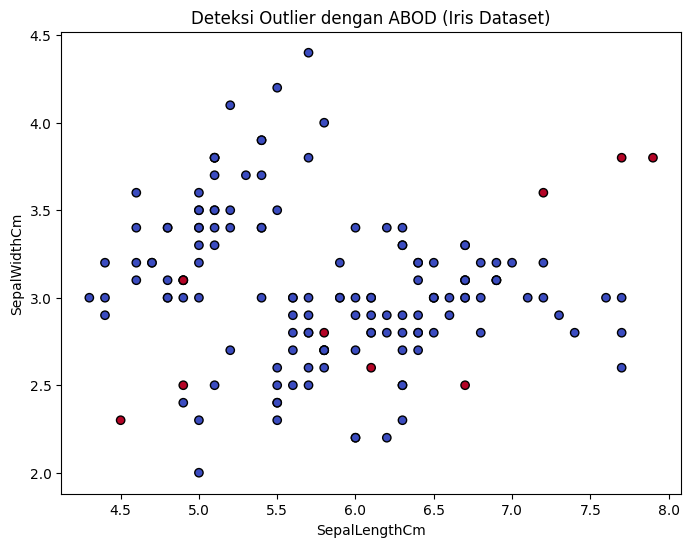

In [ ]:
# Install library PyOD (untuk ABOD)
!pip install pyod

# Import library
import pandas as pd
import matplotlib.pyplot as plt
from pyod.models.abod import ABOD

# 1. Baca data CSV
df = pd.read_csv("Iris.csv")   # ganti path jika perlu
print(df.head())

# 2. Ambil fitur numerik (buang kolom non-numerik seperti 'Species')
X = df.drop(columns=['Species', 'Id'])

# 3. Jalankan ABOD
clf = ABOD(contamination=0.05)  # 5% diasumsikan outlier
clf.fit(X)

# 4. Prediksi outlier
df['outlier'] = clf.predict(X)   # 0 = normal, 1 = outlier
df['score'] = clf.decision_function(X)  # skor outlier

print(df.head())

# 5. Visualisasi (contoh: SepalLengthCm vs SepalWidthCm)
plt.figure(figsize=(8,6))
plt.scatter(df['SepalLengthCm'], df['SepalWidthCm'],
            c=df['outlier'], cmap='coolwarm', edgecolor='k')
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Deteksi Outlier dengan ABOD (Iris Dataset)")
plt.show()

In [1]:
import sys, pycaret
print("Python:", sys.version)
print("PyCaret:", pycaret.__version__)


Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyCaret: 3.3.2


In [12]:
import pandas as pd

iris = pd.read_csv("Iris.csv")
iris = iris.drop(columns=["Id"], errors="ignore")  # drop kolom Id kalau ada

# Ambil hanya kolom numerik
iris_num = iris[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]

print(iris_num.dtypes)
iris_num.head()


SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
dtype: object


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [18]:
from pycaret.anomaly import setup

exp = setup(
    data=iris_num,
    session_id=123
)


,Description,Value
0,Session id,123
1,Original data shape,"(150, 4)"
2,Transformed data shape,"(150, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


In [19]:
from pycaret.anomaly import create_model, assign_model

# Model 1: Isolation Forest
iforest = create_model('iforest')
out_iforest = assign_model(iforest)

# Model 2: KNN
knn = create_model('knn')
out_knn = assign_model(knn)

# Model 3: LOF
lof = create_model('lof')
out_lof = assign_model(lof)

print("Isolation Forest outliers:", out_iforest['Anomaly'].sum())
print("KNN outliers:", out_knn['Anomaly'].sum())
print("LOF outliers:", out_lof['Anomaly'].sum())


Isolation Forest outliers: 8
KNN outliers: 8
LOF outliers: 8


In [21]:
import plotly.express as px

# Pilih hasil salah satu model, misalnya Isolation Forest
df_plot = out_iforest.copy()

fig = px.scatter_3d(
    df_plot,
    x='SepalLengthCm',
    y='SepalWidthCm',
    z='PetalLengthCm',
    color=df_plot['Anomaly'].map({0: 'Normal', 1: 'Outlier'}),
    symbol=df_plot['Anomaly'].map({0: 'circle', 1: 'x'}),
    opacity=0.7,
    title="3D Outlier Detection (Isolation Forest)"
)

fig.update_traces(marker=dict(size=6))
fig.show()
